In [1]:
# Patch for matplotlib_inline 0.2.2 incompatibility with newer matplotlib.
# rcParams._get was removed; this restores it before ipykernel sets up the
# inline backend (which fires on kernel startup, before any other import).
import matplotlib
if not hasattr(matplotlib.rcParams, "_get"):
    matplotlib.rcParams._get = matplotlib.rcParams.__getitem__

# keras-hexagdly → hls4ml export

This notebook shows the full path from training a hex CNN to exporting it for FPGA synthesis via [hls4ml](https://github.com/fastmachinelearning/hls4ml).

**The key idea:**  
keras-hexagdly uses a zig-zag grid representation internally — great for training on the CPU/GPU, but hls4ml cannot synthesize the HexBase sub-kernel decomposition.  
`patch_model_for_hls()` rewrites the trained model into an equivalent one built from *stock hls4ml-native layers* (`EinsumDense`, `MaxPooling1D`) that are numerically identical to the original, using the flat-pixel neighbor table derived from the same geometry.  
**The original model and its weights are never modified.**

```
Training / PC inference          hls4ml export
────────────────────────         ──────────────────────────────────
x (B, H, W, C)                   x (B, H, W, C)   ← same input
    │                                 │
    ▼                                 ▼
HexBase zig-zag conv      →   Reshape + EinsumDense   (gather folded in)
    │                                 │
    ▼                                 ▼
HexBase MaxPool           →   EinsumDense + MaxPooling1D(K,K)
    │                                 │
    ▼                                 ▼
y (same values, same shape)      y (bit-identical float32)
```

In [2]:
import numpy as np
import keras
import keras_hexagdly as hgly

# notebook utilities shared with the other notebooks
from toy_data import ToyDataset, toy_hex_image
from hexplot import plot_hextensor

2026-06-30 19:22:15.580675: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-30 19:22:15.642411: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Train a small hex CNN

Same toy setup as `keras_hexagdly_cnn_example.ipynb`: four hexagonal shapes, a two-block Conv→Pool CNN.  
Nothing here is specific to the export — this is just a normal keras-hexagdly training run.

In [3]:
shape_list = ['snowflake_2', 'snowflake_3', 'snowflake_4', 'double_hex']
H, W = 20, 20

train_data = ToyDataset(shape_list, 128, H, W).create(seed=0)
val_data   = ToyDataset(shape_list,  32, H, W).create(seed=1)
x_train, y_train = train_data.to_arrays()
x_val,   y_val   = val_data.to_arrays()
print('train:', x_train.shape, ' val:', x_val.shape)

train: (512, 20, 20, 1)  val: (128, 20, 20, 1)


In [4]:
inp = keras.Input(shape=(H, W, 1), name='image')
x = hgly.Conv2d(out_channels=8, kernel_size=1, stride=1,
                share_neighbors=True, bias=False, name='conv1')(inp)
x = keras.layers.ReLU(name='relu1')(x)
x = hgly.MaxPool2d(kernel_size=1, stride=2, name='pool1')(x)
x = keras.layers.Flatten(name='flat')(x)
x = keras.layers.Dense(32, activation='relu', name='fc1')(x)
out = keras.layers.Dense(len(shape_list), name='logits')(x)
model = keras.Model(inp, out, name='hex_cnn')

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)
model.summary()

E0000 00:00:1782840143.354275  477657 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782840143.360117  477657 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "hex_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 20, 20, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2d)                  │ (None, 20, 20, 8)      │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 20, 20, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPool2d)               │ (None, 10, 10, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flat (Flatten)                  │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,780 (100.70 KB)

 Trainable params: 25,780 (100.70 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30, verbose=0,
)
print(f'final val accuracy: {history.history["val_accuracy"][-1]:.3f}')

final val accuracy: 0.719


## 2. Verify the trained model

Quick sanity check before we export: the model should classify a test image correctly.

1.     double_hex   67.7%
2.    snowflake_3   26.1%
3.    snowflake_2    5.4%
4.    snowflake_4    0.8%


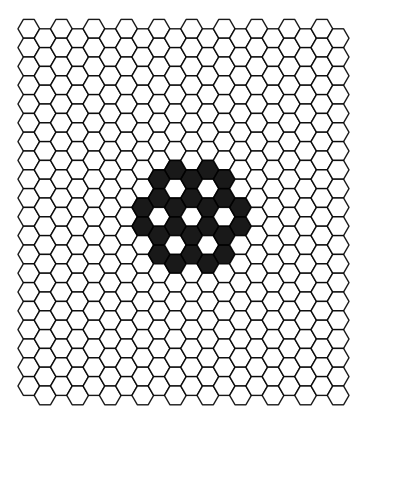

In [6]:
test_shape = 'snowflake_3'
testimage = toy_hex_image(test_shape, H, W, px=10, py=10)
plot_hextensor(testimage, figname='test_shape')

logits = model(keras.ops.convert_to_tensor(testimage))
probs  = keras.ops.convert_to_numpy(keras.ops.softmax(logits))[0]
order  = np.argsort(-probs)
for rank, idx in enumerate(order):
    tag = ' <-- correct' if shape_list[idx] == test_shape and rank == 0 else ''
    print(f'{rank+1}. {shape_list[idx]:>14s}  {100*probs[idx]:5.1f}%{tag}')

## 3. Patch the model for hls4ml

`patch_model_for_hls` returns a **new Keras model** — the original is untouched.

Internally it:
1. Sweeps single-pixel impulses through each hex layer's existing `call()` to measure the `(N_out, K)` neighbor table (no coordinate assumptions — exact by construction).
2. Folds the gather into an `EinsumDense` weight matrix for conv layers; uses `EinsumDense + MaxPooling1D` for pool layers.
3. Copies the trained weights into the replacement layers.
4. Passes all non-hex layers through unchanged.

No hls4ml dependency is needed yet — this step is pure Keras.

In [7]:
from keras_hexagdly.hls4ml_ext import patch_model_for_hls

hls_model_input = patch_model_for_hls(model, strategy="slotwise")
hls_model_input.summary()

Model: "hex_cnn_hls"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 20, 20, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_reshape_in (Reshape)      │ (None, 400, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_einsum (EinsumDense)      │ (None, 400, 8)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_reshape_out (Reshape)     │ (None, 20, 20, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 20, 20, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1_reshape_in (Reshape)      │ (None, 400, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1_gather (EinsumDense)      │ (None, 700, 8)         │       280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1_pool1d (MaxPooling1D)     │ (None, 100, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1_reshape_out (Reshape)     │ (None, 10, 10, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flat (Flatten)                  │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,585,764 (6.05 MB)

 Trainable params: 1,585,764 (6.05 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Verify bit-identical outputs

The patched model must produce **exactly the same float32 output** as the original on the same input.  
This is the correctness guarantee: if this passes, the FPGA output will match PC inference up to fixed-point quantization.

In [8]:
x_check = x_val[:8]  # a small batch

y_orig    = model.predict(x_check, verbose=0)
y_patched = hls_model_input.predict(x_check, verbose=0)

max_err = float(np.max(np.abs(y_orig - y_patched)))
print(f'max abs diff (original vs patched): {max_err:.2e}')
assert max_err < 1e-3, 'Outputs differ — something went wrong in patching!'
print('✓ outputs are numerically identical')

max abs diff (original vs patched): 7.15e-07
✓ outputs are numerically identical


## 5. Convert to hls4ml and run C-simulation

Now we hand the patched model to hls4ml.  Because all hex layers have been replaced by stock operations (`EinsumDense`, `MaxPooling1D`, `Reshape`, ...), hls4ml handles the conversion with **no custom layer** registered.

C-simulation (`hls_model.compile()` + `predict()`) runs the generated HLS C++ through g++ locally — no Vivado licence needed for this step.

In [9]:
import hls4ml

cfg = hls4ml.utils.config_from_keras_model(
    hls_model_input, granularity='name', backend='Vivado'
)
# Wider precision to keep classification accuracy in C-sim.
cfg['Model']['Precision'] = 'ap_fixed<32,12>'

hls_model = hls4ml.converters.convert_from_keras_model(
    hls_model_input,
    hls_config=cfg,
    backend='Vivado',
    output_dir='/tmp/hls_hex_cnn',
    part='xcvu9p-flga2104-2L-e',
)
print('hls4ml model created — no custom layer needed')


hls4ml model created — no custom layer needed


In [10]:
# Compile the HLS project with g++ (no Vivado needed for C-sim).
hls_model.compile()
print('C-simulation compiled successfully')

C-simulation compiled successfully


In [11]:
y_csim = hls_model.predict(np.ascontiguousarray(x_check))

csim_err = float(np.max(np.abs(y_csim - y_orig)))
print(f'max abs diff (original vs C-sim): {csim_err:.4f}')
print('(residual is fixed-point quantization, not a logic error)')

# Classification accuracy should be preserved.
pred_orig = np.argmax(y_orig, axis=1)
pred_csim = np.argmax(y_csim, axis=1)
agreement = np.mean(pred_orig == pred_csim)
print(f'class-label agreement: {100*agreement:.1f}%')

max abs diff (original vs C-sim): 0.0002
(residual is fixed-point quantization, not a logic error)
class-label agreement: 100.0%


In [13]:
import os, stat, shutil

# Add Vitis HLS 2024.2 to PATH.
VITIS_BIN = '/tools/Xilinx/Vitis_HLS/2024.2/bin'
os.environ['PATH'] = VITIS_BIN + ':' + os.environ['PATH']

# hls4ml 1.3.0 calls 'vivado_hls'; Vitis HLS 2024.2 ships only 'vitis_hls'.
# Use a wrapper script (not a symlink) so $0 resolves correctly.
shim = os.path.expanduser('~/.local/bin/vivado_hls')
if not os.path.isfile(shim) or os.path.islink(shim):
    if os.path.islink(shim): os.remove(shim)
    os.makedirs(os.path.dirname(shim), exist_ok=True)
    with open(shim, 'w') as _f:
        _f.write('#!/bin/bash\nexec /tools/Xilinx/Vitis_HLS/2024.2/bin/vitis_hls "$@"\n')
    os.chmod(shim, os.stat(shim).st_mode | stat.S_IEXEC | stat.S_IXGRP | stat.S_IXOTH)
    print('created vivado_hls wrapper')

# IMPORTANT — synthesis grid-size limit:
# The EinsumDense kernel is (N_in*Cin, N_out*Cout). Vitis HLS clang segfaults
# when this array exceeds ~50k entries. At H=W=20 (400 pixels, 8 filters) the
# kernel is 1.28M entries — too large. For synthesis we use a tiny 9x9 model
# (81 pixels, 4 filters -> 26k entries) to demonstrate the flow.
# For real deployment at camera scale, replace EinsumDense with a sparse
# gather + Dense (see hls4ml_ext.py note on resource scaling).
HS, WS = 9, 9
inp_s  = keras.Input(shape=(HS, WS, 1), name='image')
xs = hgly.Conv2d(out_channels=4, kernel_size=1, stride=1,
                 share_neighbors=True, bias=False, name='conv1')(inp_s)
xs = keras.layers.ReLU(name='relu1')(xs)
xs = keras.layers.Flatten(name='flat')(xs)
xs = keras.layers.Dense(len(shape_list), name='logits')(xs)
synth_model = keras.Model(inp_s, xs, name='hex_cnn_synth')
synth_model.compile(optimizer='adam',
                    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True))
print('synth model built (9x9 grid, 4 filters, EinsumDense kernel = 26k entries)')

synth_patched = patch_model_for_hls(synth_model)

synth_dir = '/tmp/hls_hex_cnn_synth'
if os.path.exists(synth_dir): shutil.rmtree(synth_dir)
cfg_s = hls4ml.utils.config_from_keras_model(synth_patched, granularity='name', backend='Vivado')
cfg_s['Model']['Precision'] = 'ap_fixed<16,6>'
hls_synth = hls4ml.converters.convert_from_keras_model(
    synth_patched, hls_config=cfg_s, backend='Vivado',
    output_dir=synth_dir, part='xcvu9p-flga2104-2L-e',
)
hls_synth.build(csim=False, synth=True, export=False)
hls4ml.report.read_vivado_report(synth_dir)


****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2024.2 (64-bit)
  **** SW Build 5238294 on Nov  8 2024
  **** IP Build 5239520 on Sun Nov 10 16:12:51 MST 2024
  **** SharedData Build 5239561 on Fri Nov 08 14:39:27 MST 2024
  **** Start of session at: Tue Jun 30 19:25:22 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis/2024.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] For user 'tanguy' on host 'tanguy-OptiPlex-7040' (Linux_x86_64 version 6.8.0-124-generic) on Tue Jun 30 19:25:24 CEST 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/tmp/hls_hex_cnn'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
INFO: [HLS 200-10] Creating and opening project '/tmp/hls_hex_cnn/myproject_prj'.
INFO: [HLS 200-1510] Running: set_top myproject 
INFO: [HLS 200-1510] Running: add_fil

## 6. (Optional) Synthesis with Vitis HLS

Run full RTL synthesis to get real LUT / DSP / BRAM / timing numbers.

**Grid-size constraint for synthesis:** the `EinsumDense` gather kernel is a dense
`(N_in·Cin, N_out·Cout)` matrix. Vitis HLS 2024.2's clang front-end segfaults when
this array exceeds ~50k entries. At H=W=20 (400 pixels, 8 filters) the kernel is
**1.28M entries — too large**. The synthesis cell below uses a separate tiny 9×9
model (81 pixels, 4 filters → **26k entries**) purely to demonstrate the flow.

For production deployment at camera scale (e.g. DigiCam N=1296), the
`EinsumDense` dense-gather approach must be replaced by a proper sparse gather —
this is a known open item in the export path. C-simulation (g++ based, no static
elaboration limit) works at any scale today.


## Summary

| Step | Code | What happens |
|---|---|---|
| Train | `model.fit(...)` | Normal keras-hexagdly training, zig-zag grid |
| Patch | `patch_model_for_hls(model)` | Hex layers → EinsumDense + MaxPooling1D |
| Verify | `np.max(abs(y_orig - y_patched)) < 1e-3` | Float32 bit-identical check |
| Convert | `hls4ml.converters.convert_from_keras_model(...)` | No custom layer needed |
| C-sim | `hls_model.compile(); hls_model.predict(x)` | HLS C++ correctness check |
| Synthesis | `hls_model.build(synth=True)` | Real FPGA resource / timing numbers |

The original `model` is never modified — you can continue training or saving it exactly as before.